In [42]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch, Rectangle
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 150, "font.size": 9})

PROCESSED_DIR = Path("/Users/ankitpokhrel/Desktop/NDN-Toolkit/ndnsim_analysis/processed")
FIG_DIR = Path("/Users/ankitpokhrel/Desktop/NDN-Toolkit/ndnsim_analysis/figures/detection")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TOPOLOGIES = ["dfn", "dumbbell", "tree"]
SCENARIOS = ["normal", "ifa", "cp"]

SCENARIO_COLORS = {
    "normal": "#4c72b0",
    "ifa":    "#c44e52",
    "cp":     "#dd8452"
}

ROLE_DETECT_FEATURES = {
    "consumer": ["cache_hit_ratio"],
    "router":   ["timeout_ratio", "satisfaction_ratio"],
}

# These are kept for reference in EDA/summary but not used in detector
DETECT_FEATURES = ["satisfaction_ratio", "timeout_ratio", "cache_hit_ratio"]
BASELINE_WINDOW   = 200   # first N seconds used as baseline
Z_THRESHOLD       = 2.5   # z-score threshold to flag anomaly
PERSIST_WINDOW    = 3     # persistence filter window length
ALARM_THRESHOLD   = 50    # anomaly_score > this triggers alarm

# After the ground-truth +1 shift in preprocessing, the first attack
# timestep lands at t=301 in trace-aligned time.
ATTACK_START = 301

print("Ready.")
print(f"PROCESSED_DIR : {PROCESSED_DIR}")
print(f"FIG_DIR       : {FIG_DIR}")
print(f"Detect features: {DETECT_FEATURES}")
print(f"Attack boundary: t >= {ATTACK_START}")

Ready.
PROCESSED_DIR : /Users/ankitpokhrel/Desktop/NDN-Toolkit/ndnsim_analysis/processed
FIG_DIR       : /Users/ankitpokhrel/Desktop/NDN-Toolkit/ndnsim_analysis/figures/detection
Detect features: ['satisfaction_ratio', 'timeout_ratio', 'cache_hit_ratio']
Attack boundary: t >= 301


In [43]:
full = pd.read_csv(PROCESSED_DIR / "full_dataset.csv")

print(f"Full dataset: {full.shape}")
print(f"Columns: {full.columns.tolist()}")
print(f"\nTopologies: {full['topology'].unique()}")
print(f"Scenarios : {full['scenario'].unique()}")
print(f"Time range: {full['Time'].min()} → {full['Time'].max()}")

Full dataset: (60918, 25)
Columns: ['Time', 'Node', 'InData', 'InInterests', 'InNacks', 'InSatisfiedInterests', 'InTimedOutInterests', 'OutInterests', 'CacheHits', 'CacheMisses', 'delay_mean', 'delay_p95', 'retx_mean', 'hop_mean', 'n_satisfied', 'cache_hit_ratio', 'satisfaction_ratio', 'timeout_ratio', 'nack_ratio', 'interest_amp', 'data_ratio', 'role', 'label', 'topology', 'scenario']

Topologies: <StringArray>
['dfn', 'dumbbell', 'tree']
Length: 3, dtype: str
Scenarios : <StringArray>
['normal', 'ifa', 'cp']
Length: 3, dtype: str
Time range: 1 → 599


In [44]:
# ── Diagnostic: z-score distributions per role in normal vs attack ─────────

train_normal = pd.read_csv(PROCESSED_DIR / "train_normal.csv")

ROLE_DETECT_FEATURES = {
    "consumer": ["cache_hit_ratio"],
    "router":   ["timeout_ratio", "satisfaction_ratio"],
}

print("Z-score distribution analysis (using per-node baselines from first 200s)\n")

for topo in TOPOLOGIES:
    df_topo_normal = train_normal[train_normal["topology"] == topo]

    for role in ["consumer", "router"]:
        feats = ROLE_DETECT_FEATURES[role]
        nodes = df_topo_normal[df_topo_normal["role"] == role]["Node"].unique()

        z_buckets = {"normal": [], "ifa": [], "cp": []}

        for node in nodes:
            baseline = df_topo_normal[
                (df_topo_normal["Node"] == node) &
                (df_topo_normal["Time"] <= BASELINE_WINDOW)
            ]
            if len(baseline) < 5:
                continue

            stats = {
                f: (baseline[f].mean(), max(baseline[f].std(), 1e-9))
                for f in feats
            }

            for scenario in ["normal", "ifa", "cp"]:
                node_data = full[
                    (full["topology"] == topo) &
                    (full["Node"] == node) &
                    (full["scenario"] == scenario) &
                    (full["Time"] >= ATTACK_START)
                ]
                if len(node_data) == 0:
                    continue

                z_cols = []
                for f in feats:
                    mu, sigma = stats[f]
                    z_cols.append(((node_data[f] - mu) / sigma).abs())

                z_mean = pd.concat(z_cols, axis=1).mean(axis=1)
                z_buckets[scenario].extend(z_mean.tolist())

        print(f"{topo.upper()} — {role}")
        print(f"  {'Scenario':<10} {'mean':>6} {'p50':>6} {'p75':>6} "
              f"{'p90':>6} {'p95':>6} {'p99':>6} {'max':>7}")

        for scenario in ["normal", "ifa", "cp"]:
            vals = z_buckets[scenario]
            if len(vals) == 0:
                print(f"  {scenario:<10} {'(no data)':>6}")
                continue
            arr = np.array(vals)
            print(f"  {scenario:<10} "
                  f"{arr.mean():>6.2f} "
                  f"{np.percentile(arr, 50):>6.2f} "
                  f"{np.percentile(arr, 75):>6.2f} "
                  f"{np.percentile(arr, 90):>6.2f} "
                  f"{np.percentile(arr, 95):>6.2f} "
                  f"{np.percentile(arr, 99):>6.2f} "
                  f"{arr.max():>7.2f}")
        print()

Z-score distribution analysis (using per-node baselines from first 200s)

DFN — consumer
  Scenario     mean    p50    p75    p90    p95    p99     max
  normal       0.38   0.37   0.39   0.40   0.40   0.40    0.90
  ifa          6.97   6.88   7.18   7.38   7.38   7.38    7.38
  cp           2.49   0.39   6.57   6.78   6.84   6.91    6.91

DFN — router
  Scenario     mean    p50    p75    p90    p95    p99     max
  normal     33723524.92   2.65   2.90   5.06 500000000.77 500000000.77 500000000.77
  ifa        160389404.16   1.87 454545454.77 511111106.66 511111122.27 511111142.60 511111161.09
  cp         68161577.63   2.20   5.11 500000000.00 500000000.00 1000000000.00 1000000000.00

DUMBBELL — consumer
  Scenario     mean    p50    p75    p90    p95    p99     max
  normal       0.37   0.37   0.37   0.37   0.37   0.37    0.83
  ifa          6.78   6.81   6.84   6.84   6.84   6.84    6.84
  cp           4.56   6.57   6.68   6.75   6.81   6.81    6.81

DUMBBELL — router
  Scenario    

In [45]:
# ── Per-node std inspection for routers ───────────────────────────────────
# Find which router nodes have near-zero std in their baseline window,
# causing the 1e-9 floor to produce astronomical z-scores.

print("Router baseline std per node (first 200s of normal)\n")
print(f"{'Topology':<12} {'Node':>5} {'sat_ratio std':>15} "
      f"{'timeout std':>13} {'n_rows':>7} {'issue'}")
print("-" * 70)

problem_nodes = []

for topo in TOPOLOGIES:
    df_topo_normal = train_normal[train_normal["topology"] == topo]
    router_nodes = df_topo_normal[
        df_topo_normal["role"] == "router"
    ]["Node"].unique()

    for node in sorted(router_nodes):
        baseline = df_topo_normal[
            (df_topo_normal["Node"] == node) &
            (df_topo_normal["Time"] <= BASELINE_WINDOW)
        ]

        sat_vals = baseline["satisfaction_ratio"]
        tmo_vals = baseline["timeout_ratio"]

        sat_std = sat_vals.std()
        tmo_std = tmo_vals.std()
        sat_mean = sat_vals.mean()
        tmo_mean = tmo_vals.mean()

        issues = []
        if sat_std < 0.01:
            issues.append(f"sat_std={sat_std:.6f}")
        if tmo_std < 0.01:
            issues.append(f"tmo_std={tmo_std:.6f}")
        # Also flag nodes where mean is 0 — feature always zero
        if sat_mean == 0:
            issues.append("sat always 0")
        if tmo_mean == 0:
            issues.append("tmo always 0")

        issue_str = ", ".join(issues) if issues else "ok"
        flag = " ← BROKEN" if issues else ""

        print(f"{topo:<12} {node:>5} {sat_std:>15.6f} "
              f"{tmo_std:>13.6f} {len(baseline):>7} {issue_str}{flag}")

        if issues:
            problem_nodes.append((topo, node, issues))

print(f"\n{len(problem_nodes)} problem nodes found.")

# Also show value distributions for a sample problem node
if problem_nodes:
    sample_topo, sample_node, _ = problem_nodes[0]
    sample = train_normal[
        (train_normal["topology"] == sample_topo) &
        (train_normal["Node"] == sample_node) &
        (train_normal["Time"] <= BASELINE_WINDOW)
    ]
    print(f"\nValue distribution for {sample_topo} node {sample_node} "
          f"in baseline window:")
    print(sample[["satisfaction_ratio", "timeout_ratio",
                   "InInterests", "InSatisfiedInterests",
                   "InTimedOutInterests"]].describe().round(4))

Router baseline std per node (first 200s of normal)

Topology      Node   sat_ratio std   timeout std  n_rows issue
----------------------------------------------------------------------
dfn              0        0.000000      0.457187     200 sat_std=0.000000 ← BROKEN
dfn              1        0.000000      0.000000     200 sat_std=0.000000, tmo_std=0.000000, sat always 0, tmo always 0 ← BROKEN
dfn              2        0.106233      0.500352     200 ok
dfn              3        0.223377      0.490508     200 ok
dfn              4        0.281663      0.482638     200 ok
dfn              5        0.265278      0.346942     200 ok
dumbbell         3        0.000000      0.459408     200 sat_std=0.000000 ← BROKEN
dumbbell         4        0.000000      0.000000     200 sat_std=0.000000, tmo_std=0.000000, sat always 0, tmo always 0 ← BROKEN
dumbbell         5        0.137072      0.492430     200 ok
dumbbell         6        0.000000      0.459408     200 sat_std=0.000000 ← BROKEN
dumbbe

In [46]:
ROLE_DETECT_FEATURES = {
    "consumer": ["cache_hit_ratio"],
    "router":   ["satisfaction_ratio", "timeout_ratio"],
}

print("Role-specific detection features:", ROLE_DETECT_FEATURES)


def compute_baseline_stats(df_normal, topologies, baseline_window=BASELINE_WINDOW):
    """
    Compute per-(topology, node, feature) baseline stats with data-driven
    std floors.

    Problem: some router nodes have satisfaction_ratio always = 1.0 in normal
    (std = 0). Using 1e-9 as std floor produces z-scores of ~5e8 for any
    deviation, making the detector useless.

    Fix: for any feature where a node's std < MIN_STD_FLOOR, replace it with
    the median std of that feature across all same-role nodes that DO have
    real variance (std >= MIN_STD_FLOOR). This preserves the detection signal
    (a drop from 1.0 IS anomalous) while keeping z-scores in a sane range.

    Additionally, for nodes where satisfaction_ratio is always 1.0, the
    z-score direction matters: only drops (negative deviation) are anomalous,
    not rises. We encode this with a 'direction' flag per feature per node:
      'both'  — flag deviations in either direction (default)
      'down'  — flag only drops below baseline (e.g. sat_ratio always 1.0)
      'up'    — flag only rises above baseline (e.g. timeout always 0)
    """
    MIN_STD_FLOOR = 0.05  # below this, std is considered degenerate

    df_train = df_normal[df_normal["topology"].isin(topologies)]
    baseline_data = df_train[df_train["Time"] <= baseline_window]

    # Step 1: compute raw per-node stats
    raw_stats = {}
    for topo in topologies:
        df_topo = baseline_data[baseline_data["topology"] == topo]
        for node in df_topo["Node"].unique():
            role = df_topo[df_topo["Node"] == node]["role"].iloc[0]
            feats = ROLE_DETECT_FEATURES[role]
            node_data = df_topo[df_topo["Node"] == node]
            raw_stats[(topo, node)] = {
                "role": role,
                "feats": {}
            }
            for f in feats:
                mu    = node_data[f].mean()
                sigma = node_data[f].std()
                raw_stats[(topo, node)]["feats"][f] = {
                    "mu": mu, "sigma": sigma
                }

    # Step 2: compute peer median std per (role, feature) for floor replacement
    peer_median_std = {}
    for role, feats in ROLE_DETECT_FEATURES.items():
        peer_median_std[role] = {}
        for f in feats:
            real_stds = [
                v["feats"][f]["sigma"]
                for v in raw_stats.values()
                if v["role"] == role
                and f in v["feats"]
                and v["feats"][f]["sigma"] >= MIN_STD_FLOOR
            ]
            if real_stds:
                peer_median_std[role][f] = float(np.median(real_stds))
            else:
                peer_median_std[role][f] = MIN_STD_FLOOR
            print(f"  Peer median std — {role} {f}: "
                  f"{peer_median_std[role][f]:.4f} "
                  f"(from {len(real_stds)} nodes with real variance)")

    # Step 3: build final baselines with floored stds and direction flags
    print(f"\n  {'Topo':<10} {'Node':>5} {'Role':<10} {'Feature':<22} "
          f"{'mu':>7} {'sigma':>7} {'floored':>8} {'direction'}")
    print("  " + "-" * 80)

    baselines = {}
    for (topo, node), info in raw_stats.items():
        role  = info["role"]
        stats = {}
        for f, fstats in info["feats"].items():
            mu    = fstats["mu"]
            sigma = fstats["sigma"]
            floored = False

            if sigma < MIN_STD_FLOOR:
                sigma   = peer_median_std[role][f]
                floored = True

            # Direction flag:
            # If mu > 0.95 (feature nearly always 1.0 in normal), only
            # drops are anomalous — a rise above 1.0 is impossible anyway.
            # If mu < 0.05 (feature nearly always 0.0 in normal), only
            # rises are anomalous.
            # Otherwise flag both directions.
            if mu > 0.95:
                direction = "down"
            elif mu < 0.05:
                direction = "up"
            else:
                direction = "both"

            stats[f] = {
                "mu":        mu,
                "sigma":     sigma,
                "direction": direction,
            }
            print(f"  {topo:<10} {node:>5} {role:<10} {f:<22} "
                  f"{mu:>7.4f} {sigma:>7.4f} "
                  f"{'YES' if floored else 'no':>8} {direction}")

        baselines[(topo, node)] = {"role": role, "stats": stats}

    return baselines


def run_detector(df_input, baselines,
                 z_thresh=Z_THRESHOLD, persist=PERSIST_WINDOW):
    """
    Per-node z-score detector with persistence filter and direction-aware
    flagging.

    For features with direction='down', only flag when value drops below
    baseline (z-score is negative before abs — we check signed deviation).
    For features with direction='up', only flag rises.
    For features with direction='both', flag absolute deviation (original).
    """
    results = []
    missing_keys = []

    for topo in df_input["topology"].unique():
        for node in df_input[df_input["topology"] == topo]["Node"].unique():
            key = (topo, node)
            if key not in baselines:
                missing_keys.append(key)
                continue

            role  = baselines[key]["role"]
            stats = baselines[key]["stats"]
            feats = ROLE_DETECT_FEATURES[role]

            for scenario in SCENARIOS:
                node_data = df_input[
                    (df_input["topology"] == topo) &
                    (df_input["Node"] == node) &
                    (df_input["scenario"] == scenario)
                ].sort_values("Time").copy()

                if len(node_data) < 2:
                    continue

                z = pd.DataFrame(index=node_data.index)
                for feat in feats:
                    mu        = stats[feat]["mu"]
                    sigma     = stats[feat]["sigma"]
                    direction = stats[feat]["direction"]

                    signed_z = (node_data[feat] - mu) / sigma

                    if direction == "down":
                        # Only flag drops — negative signed z
                        z[feat] = (-signed_z).clip(lower=0)
                    elif direction == "up":
                        # Only flag rises — positive signed z
                        z[feat] = signed_z.clip(lower=0)
                    else:
                        # Flag both directions
                        z[feat] = signed_z.abs()

                node_data["z_mean"] = z.mean(axis=1)
                flagged = (node_data["z_mean"] > z_thresh).astype(int)
                persist_score = (
                    flagged.rolling(persist, min_periods=1).sum() / persist
                )
                node_data["anomaly_score"] = (persist_score * 100).clip(0, 100)
                results.append(node_data)

    if missing_keys:
        print(f"WARNING: no baseline for {len(missing_keys)} pairs: "
              f"{missing_keys[:5]}...")

    return pd.concat(results, ignore_index=True)


# ── Build and run ──────────────────────────────────────────────────────────
train_normal = pd.read_csv(PROCESSED_DIR / "train_normal.csv")
print(f"train_normal: {train_normal.shape}\n")

print("Building leave-one-out global baselines...\n")
global_scored_parts = []

for target_topo in TOPOLOGIES:
    training_topos = [t for t in TOPOLOGIES if t != target_topo]
    print(f"\nTarget: {target_topo} | Training on: {training_topos}")

    loo_baselines = compute_baseline_stats(train_normal, training_topos)

    # Remap baselines to target topology nodes using role matching
    # (LOO: we know target topology's node roles but not their individual stats)
    df_target_normal = train_normal[train_normal["topology"] == target_topo]

    target_baselines = {}
    for node in df_target_normal["Node"].unique():
        role = df_target_normal[
            df_target_normal["Node"] == node
        ]["role"].iloc[0]

        # Find same-role nodes from training topologies and average their stats
        peer_stats_list = [
            v["stats"] for (topo, n), v in loo_baselines.items()
            if v["role"] == role
        ]
        if not peer_stats_list:
            continue

        # Average mu and sigma across peers; keep majority-vote direction
        merged_stats = {}
        for f in ROLE_DETECT_FEATURES[role]:
            mus       = [s[f]["mu"]    for s in peer_stats_list if f in s]
            sigmas    = [s[f]["sigma"] for s in peer_stats_list if f in s]
            dirs      = [s[f]["direction"] for s in peer_stats_list if f in s]
            if not mus:
                continue
            avg_mu    = float(np.mean(mus))
            avg_sigma = float(np.mean(sigmas))
            # Direction: use the mode
            direction = max(set(dirs), key=dirs.count)
            merged_stats[f] = {
                "mu": avg_mu, "sigma": avg_sigma, "direction": direction
            }

        target_baselines[(target_topo, node)] = {
            "role": role, "stats": merged_stats
        }

    scored_topo = run_detector(
        full[full["topology"] == target_topo],
        target_baselines
    )
    scored_topo["model"] = "global_loo"
    global_scored_parts.append(scored_topo)

full_scored = pd.concat(global_scored_parts, ignore_index=True)
full_scored["model"] = "global_loo"

print(f"\nGlobal LOO scored dataset: {full_scored.shape}")
print("\nAnomaly score distribution by scenario:")
print(full_scored.groupby("scenario")["anomaly_score"].describe().round(2))

print("\nAnomaly score by role × scenario:")
print(
    full_scored.groupby(["role", "scenario"])["anomaly_score"]
    .mean().round(2).unstack()
)

print(f"\nBefore/after t={ATTACK_START} — Global LOO model:")
for topo in TOPOLOGIES:
    for attack in ["ifa", "cp"]:
        g = full_scored[
            (full_scored["topology"] == topo) &
            (full_scored["scenario"] == attack)
        ]
        pre  = g[g["Time"] <  ATTACK_START]["anomaly_score"].mean()
        post = g[g["Time"] >= ATTACK_START]["anomaly_score"].mean()
        print(f"  {topo}-{attack}: pre={pre:.1f}  post={post:.1f}  "
              f"lift={post-pre:.1f}")

Role-specific detection features: {'consumer': ['cache_hit_ratio'], 'router': ['satisfaction_ratio', 'timeout_ratio']}
train_normal: (20366, 25)

Building leave-one-out global baselines...


Target: dfn | Training on: ['dumbbell', 'tree']
  Peer median std — consumer cache_hit_ratio: 0.1387 (from 9 nodes with real variance)
  Peer median std — router satisfaction_ratio: 0.1371 (from 5 nodes with real variance)
  Peer median std — router timeout_ratio: 0.4594 (from 11 nodes with real variance)

  Topo        Node Role       Feature                     mu   sigma  floored direction
  --------------------------------------------------------------------------------
  dumbbell       0 consumer   cache_hit_ratio         0.9486  0.1417       no both
  dumbbell       1 consumer   cache_hit_ratio         0.9486  0.1387       no both
  dumbbell       2 consumer   cache_hit_ratio         0.9486  0.1392       no both
  dumbbell       3 router     satisfaction_ratio      1.0000  0.1371      YES dow

In [47]:
print("Anomaly score by ground-truth label:")
print(full_scored.groupby("label")["anomaly_score"].describe().round(2))

print(f"\nBefore/after t={ATTACK_START} for each topology-attack:")
for topo in TOPOLOGIES:
    for attack in ["ifa", "cp"]:
        grp = full_scored[
            (full_scored["topology"] == topo) &
            (full_scored["scenario"] == attack)
        ]
        pre  = grp[grp["Time"] <  ATTACK_START]["anomaly_score"].mean()
        post = grp[grp["Time"] >= ATTACK_START]["anomaly_score"].mean()
        lift = post - pre
        print(f"  {topo}-{attack}: pre={pre:.1f}  post={post:.1f}  lift={lift:.1f}")

# IFA-specific note: IFA legitimate consumers use ConsumerCbr (flat),
# while the normal baseline was built from Zipf-Mandelbrot traffic.
# This distributional difference means IFA lift figures include a component
# from the consumer model change, not purely from the attack itself.
# CP lift figures are cleaner in this regard (Zipf-Mandelbrot throughout).
print("\nNOTE: IFA lift is partially confounded by ConsumerCbr vs Zipf-Mandelbrot"
      " baseline mismatch (see scenarios_info.md). Treat IFA and CP lift"
      " numbers as not directly comparable.")

Anomaly score by ground-truth label:
          count   mean    std  min  25%  50%    75%    max
label                                                     
cp      10166.0  17.59  38.04  0.0  0.0  0.0    0.0  100.0
ifa     10166.0  44.12  49.66  0.0  0.0  0.0  100.0  100.0
normal  40586.0  11.78  31.92  0.0  0.0  0.0    0.0  100.0

Before/after t=301 for each topology-attack:
  dfn-ifa: pre=49.8  post=50.0  lift=0.2
  dfn-cp: pre=1.7  post=16.6  lift=14.9
  dumbbell-ifa: pre=29.9  post=30.0  lift=0.1
  dumbbell-cp: pre=1.0  post=19.9  lift=18.9
  tree-ifa: pre=49.8  post=50.0  lift=0.2
  tree-cp: pre=1.7  post=16.6  lift=14.9

NOTE: IFA lift is partially confounded by ConsumerCbr vs Zipf-Mandelbrot baseline mismatch (see scenarios_info.md). Treat IFA and CP lift numbers as not directly comparable.


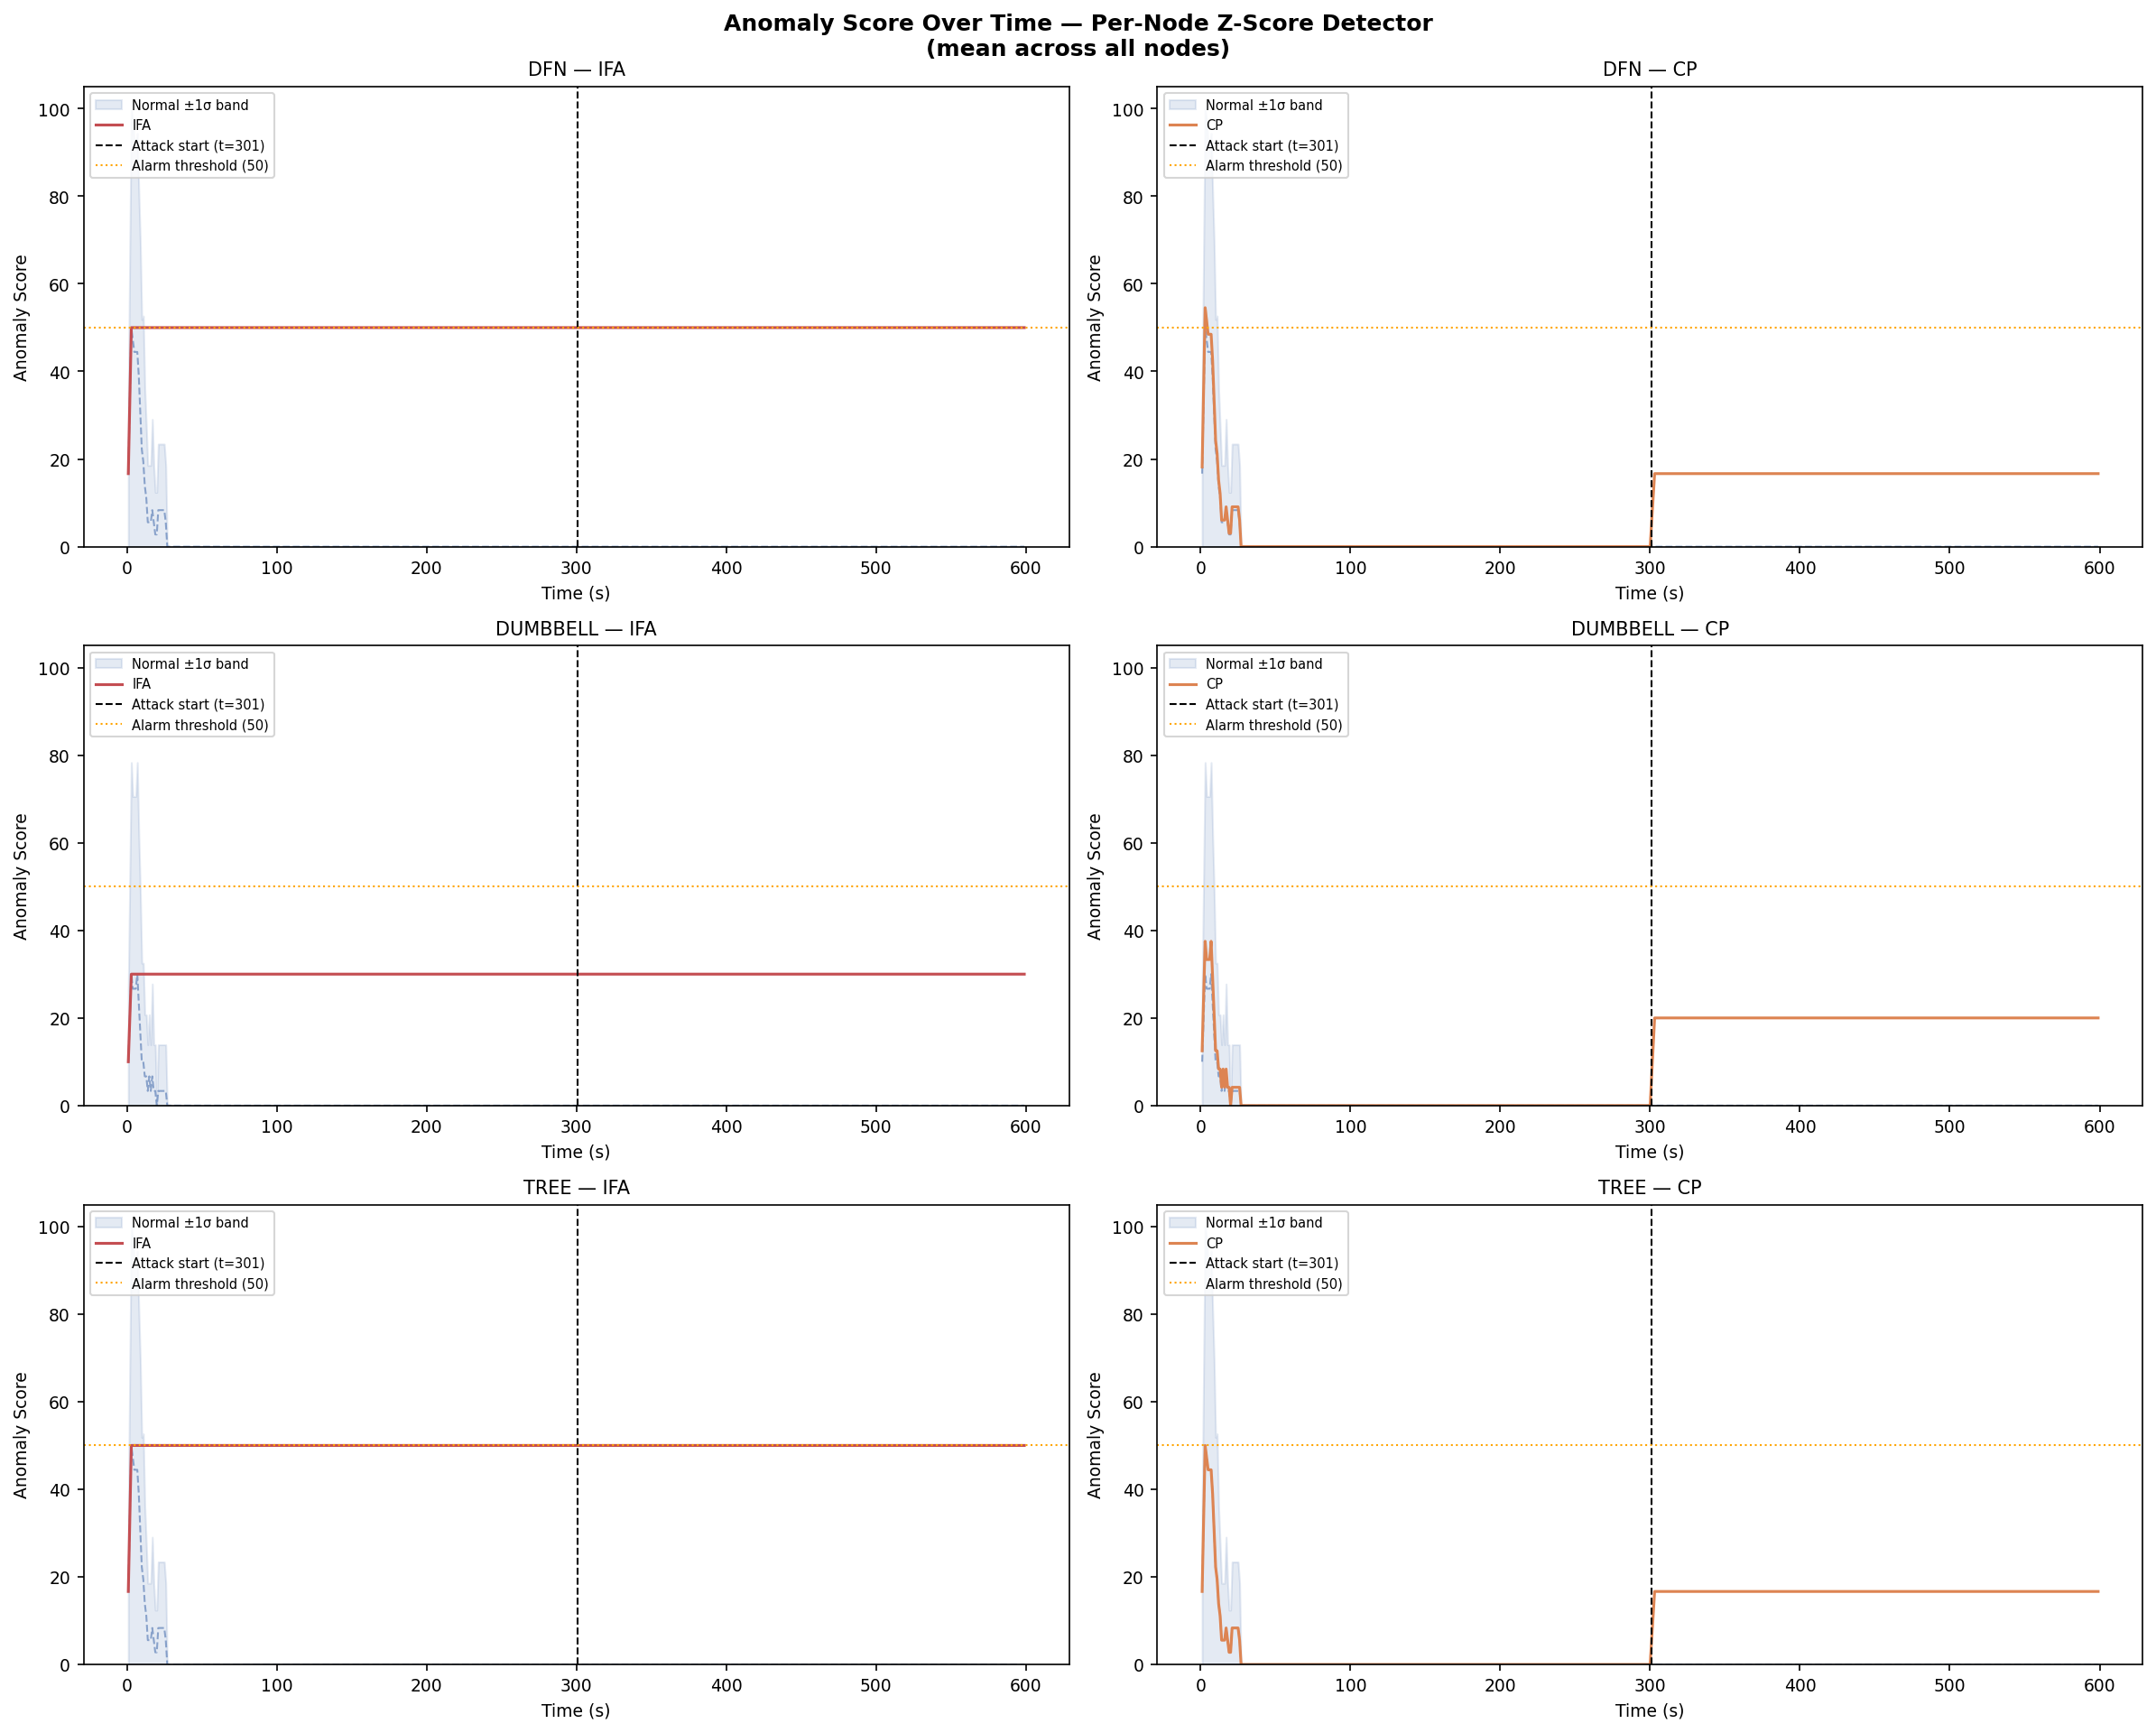

Saved fig_score_timeseries.png


In [48]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13))

for row, topo in enumerate(TOPOLOGIES):
    for col, attack in enumerate(["ifa", "cp"]):
        ax = axes[row][col]

        norm_ts = full_scored[
            (full_scored["topology"] == topo) &
            (full_scored["scenario"] == "normal")
        ].groupby("Time")["anomaly_score"]
        norm_mean = norm_ts.mean()
        norm_std  = norm_ts.std()

        ax.fill_between(norm_mean.index,
                         (norm_mean - norm_std).clip(0),
                         (norm_mean + norm_std).clip(0, 100),
                         alpha=0.15, color=SCENARIO_COLORS["normal"],
                         label="Normal ±1σ band")
        ax.plot(norm_mean.index, norm_mean.values,
                color=SCENARIO_COLORS["normal"],
                linewidth=1.0, alpha=0.6, linestyle="--")

        atk_ts = full_scored[
            (full_scored["topology"] == topo) &
            (full_scored["scenario"] == attack)
        ].groupby("Time")["anomaly_score"].mean()

        ax.plot(atk_ts.index, atk_ts.values,
                color=SCENARIO_COLORS[attack],
                linewidth=1.5, label=attack.upper())

        # Corrected: attack starts at ATTACK_START (t=301), not t=300
        ax.axvline(ATTACK_START, color="black", linestyle="--",
                   linewidth=1.0, label=f"Attack start (t={ATTACK_START})")
        ax.axhline(ALARM_THRESHOLD, color="orange", linestyle=":",
                   linewidth=1.0, label=f"Alarm threshold ({ALARM_THRESHOLD})")
        ax.fill_between(atk_ts.index, atk_ts.values, ALARM_THRESHOLD,
                        where=(atk_ts.values > ALARM_THRESHOLD),
                        alpha=0.25, color=SCENARIO_COLORS[attack])

        ax.set_title(f"{topo.upper()} — {attack.upper()}", fontsize=10)
        ax.set_ylim(0, 105)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Anomaly Score")
        ax.legend(fontsize=7, loc="upper left")

fig.suptitle("Anomaly Score Over Time — Per-Node Z-Score Detector\n(mean across all nodes)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_score_timeseries.png", bbox_inches="tight")
plt.show()
print("Saved fig_score_timeseries.png")

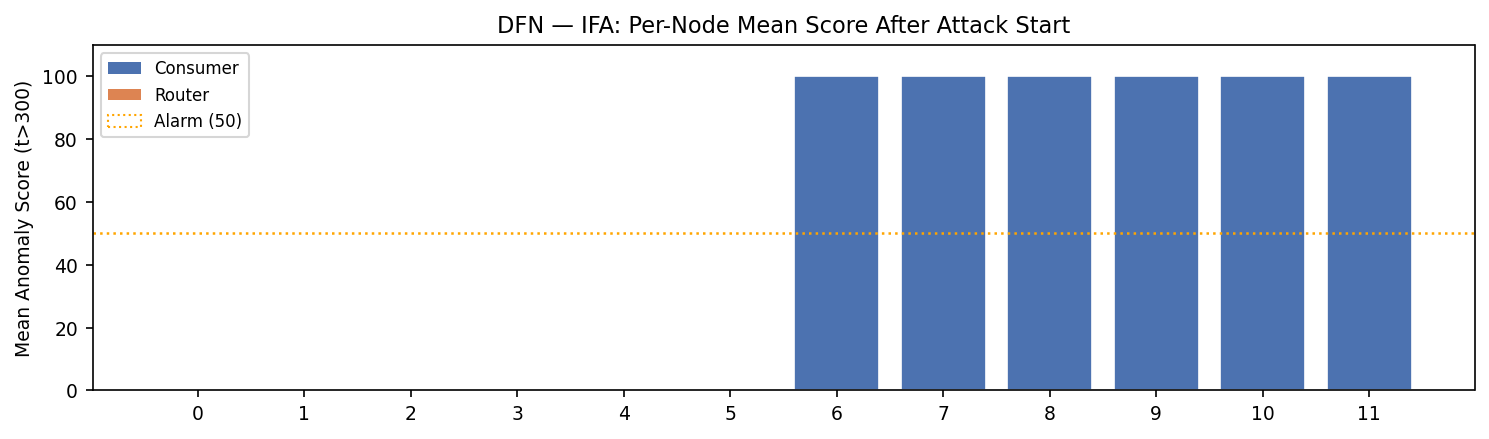

Saved fig_pernode_scores_dfn_ifa.png


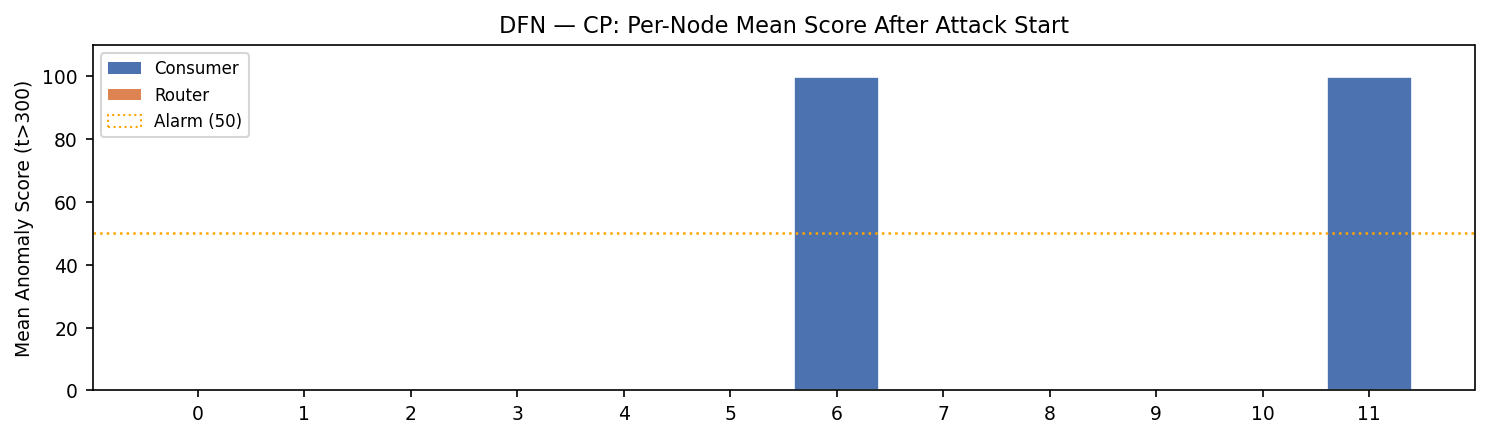

Saved fig_pernode_scores_dfn_cp.png


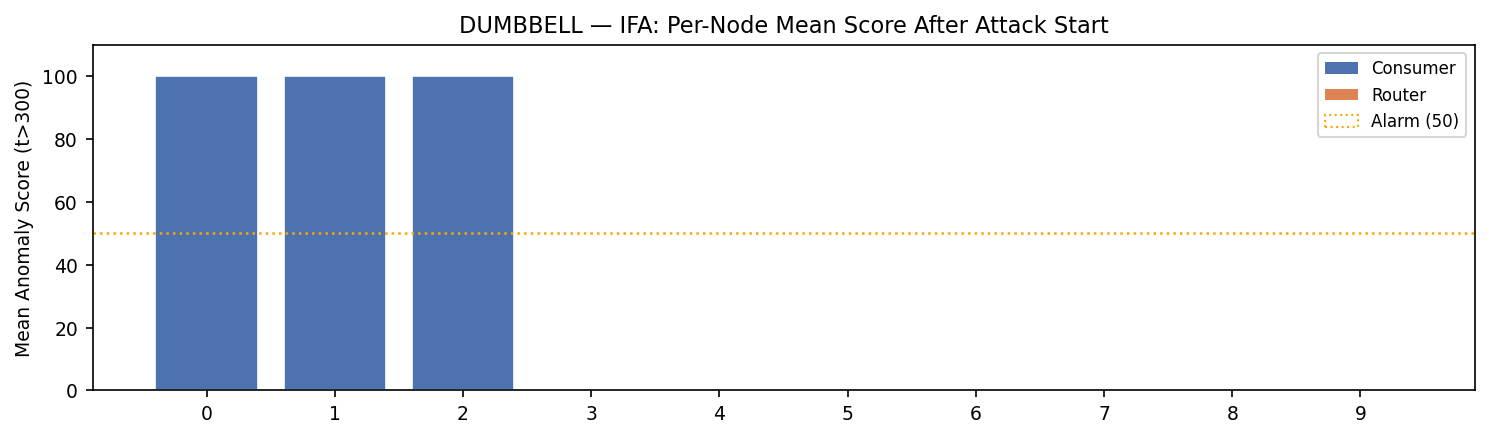

Saved fig_pernode_scores_dumbbell_ifa.png


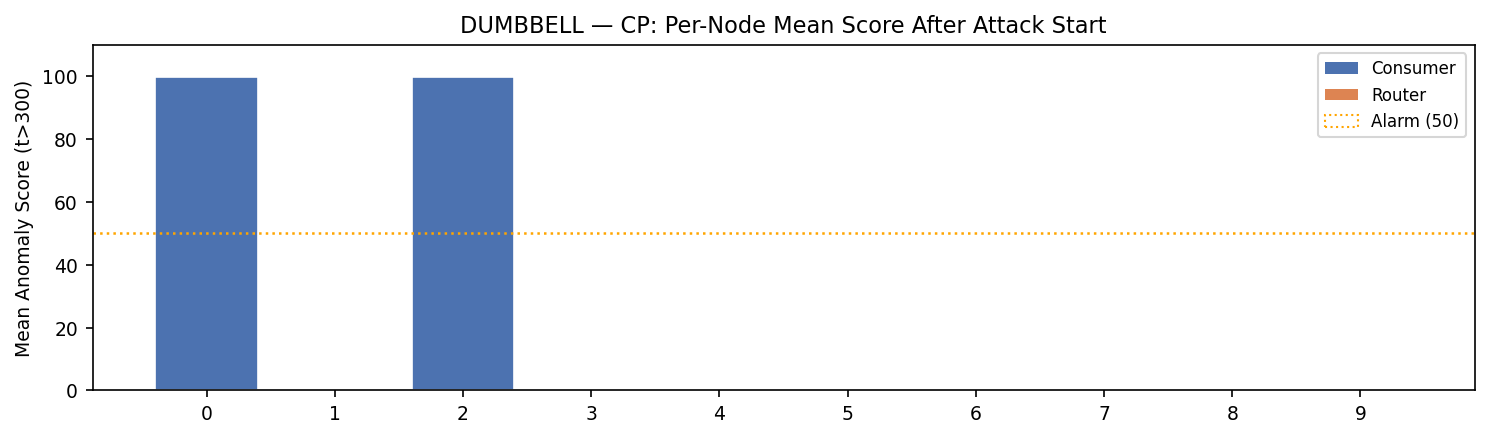

Saved fig_pernode_scores_dumbbell_cp.png


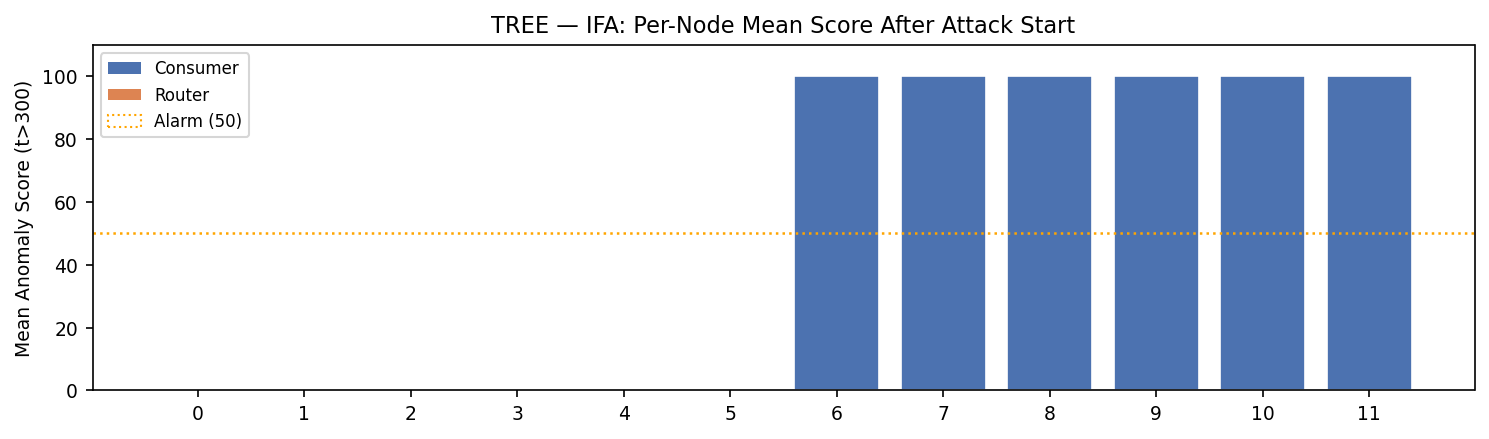

Saved fig_pernode_scores_tree_ifa.png


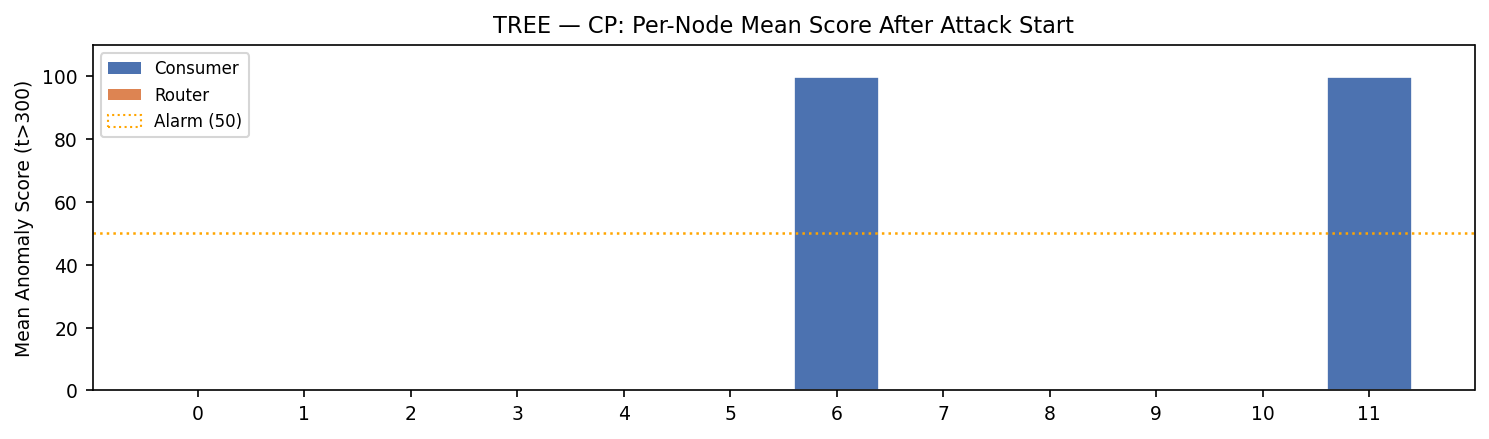

Saved fig_pernode_scores_tree_cp.png


In [49]:
def plot_pernode_heatmap(topo, attack):
    grp = full_scored[
        (full_scored["topology"]==topo) &
        (full_scored["scenario"]==attack) &
        (full_scored["Time"] > 300)
    ]
    nodes         = sorted(grp["Node"].unique())
    node_scores   = grp.groupby("Node")["anomaly_score"].mean()
    roles         = full_scored[full_scored["topology"]==topo].groupby("Node")["role"].first()

    fig, ax = plt.subplots(figsize=(10, 3))
    colors = [ROLE_COLORS[roles[n]] for n in nodes]
    bars   = ax.bar(range(len(nodes)), [node_scores.get(n, 0) for n in nodes],
                    color=colors, edgecolor="white", linewidth=0.8)

    ax.axhline(ALARM_THRESHOLD, color="orange", linestyle=":",
               linewidth=1.2, label=f"Alarm threshold ({ALARM_THRESHOLD})")
    ax.set_xticks(range(len(nodes)))
    ax.set_xticklabels(nodes, fontsize=9)
    ax.set_ylim(0, 110)
    ax.set_ylabel("Mean Anomaly Score (t>300)")
    ax.set_title(f"{topo.upper()} — {attack.upper()}: Per-Node Mean Score After Attack Start")

    legend_handles = [
        Patch(facecolor=ROLE_COLORS["consumer"], label="Consumer"),
        Patch(facecolor=ROLE_COLORS["router"],   label="Router"),
        mpatches.Patch(facecolor="none", edgecolor="orange",
                       linestyle=":", label=f"Alarm ({ALARM_THRESHOLD})")
    ]
    ax.legend(handles=legend_handles, fontsize=8)
    plt.tight_layout()
    fname = FIG_DIR / f"fig_pernode_scores_{topo}_{attack}.png"
    plt.savefig(fname, bbox_inches="tight")
    plt.show()
    print(f"Saved {fname.name}")

for topo in TOPOLOGIES:
    for attack in ["ifa", "cp"]:
        plot_pernode_heatmap(topo, attack)

In [50]:
latency_rows = []

for topo in TOPOLOGIES:
    for attack in ["ifa", "cp"]:
        for node in full_scored[full_scored["topology"] == topo]["Node"].unique():
            grp = full_scored[
                (full_scored["topology"] == topo) &
                (full_scored["scenario"] == attack) &
                (full_scored["Node"] == node)
            ].sort_values("Time")

            # First alarm at or after the true attack start
            post = grp[grp["Time"] >= ATTACK_START]
            alarm_times = post[post["anomaly_score"] > ALARM_THRESHOLD]["Time"]

            if len(alarm_times) > 0:
                first_alarm = int(alarm_times.iloc[0])
                latency = first_alarm - ATTACK_START
                # Sanity check: persistence filter requires at least PERSIST_WINDOW steps
                # so minimum credible latency is PERSIST_WINDOW - 1 = 2
                # (the filter can trigger on the Nth step where N=PERSIST_WINDOW)
                if latency < (PERSIST_WINDOW - 1):
                    print(f"  WARNING: {topo}-{attack} node {node} latency={latency}s "
                          f"is below persistence window floor ({PERSIST_WINDOW-1}s). "
                          f"Check time alignment.")
                detected = True
            else:
                latency  = None
                detected = False

            role = grp["role"].iloc[0] if len(grp) > 0 else "unknown"
            latency_rows.append({
                "topology":  topo,
                "attack":    attack,
                "node":      node,
                "role":      role,
                "detected":  detected,
                "latency_s": latency
            })

df_latency = pd.DataFrame(latency_rows)

print("Detection rate and mean latency by topology-attack:")
summary = df_latency.groupby(["topology", "attack"]).agg(
    detection_rate  = ("detected",  "mean"),
    mean_latency_s  = ("latency_s", "mean"),
    min_latency_s   = ("latency_s", "min"),
    nodes_detected  = ("detected",  "sum"),
    total_nodes     = ("detected",  "count")
).round(2)
print(summary.to_string())

df_latency.to_csv(PROCESSED_DIR / "detection_latency.csv", index=False)
print("\nSaved detection_latency.csv")

Detection rate and mean latency by topology-attack:
                 detection_rate  mean_latency_s  min_latency_s  nodes_detected  total_nodes
topology attack                                                                            
dfn      cp                0.17             1.0            1.0               2           12
         ifa               0.50             0.0            0.0               6           12
dumbbell cp                0.20             1.0            1.0               2           10
         ifa               0.30             0.0            0.0               3           10
tree     cp                0.17             1.0            1.0               2           12
         ifa               0.50             0.0            0.0               6           12

Saved detection_latency.csv


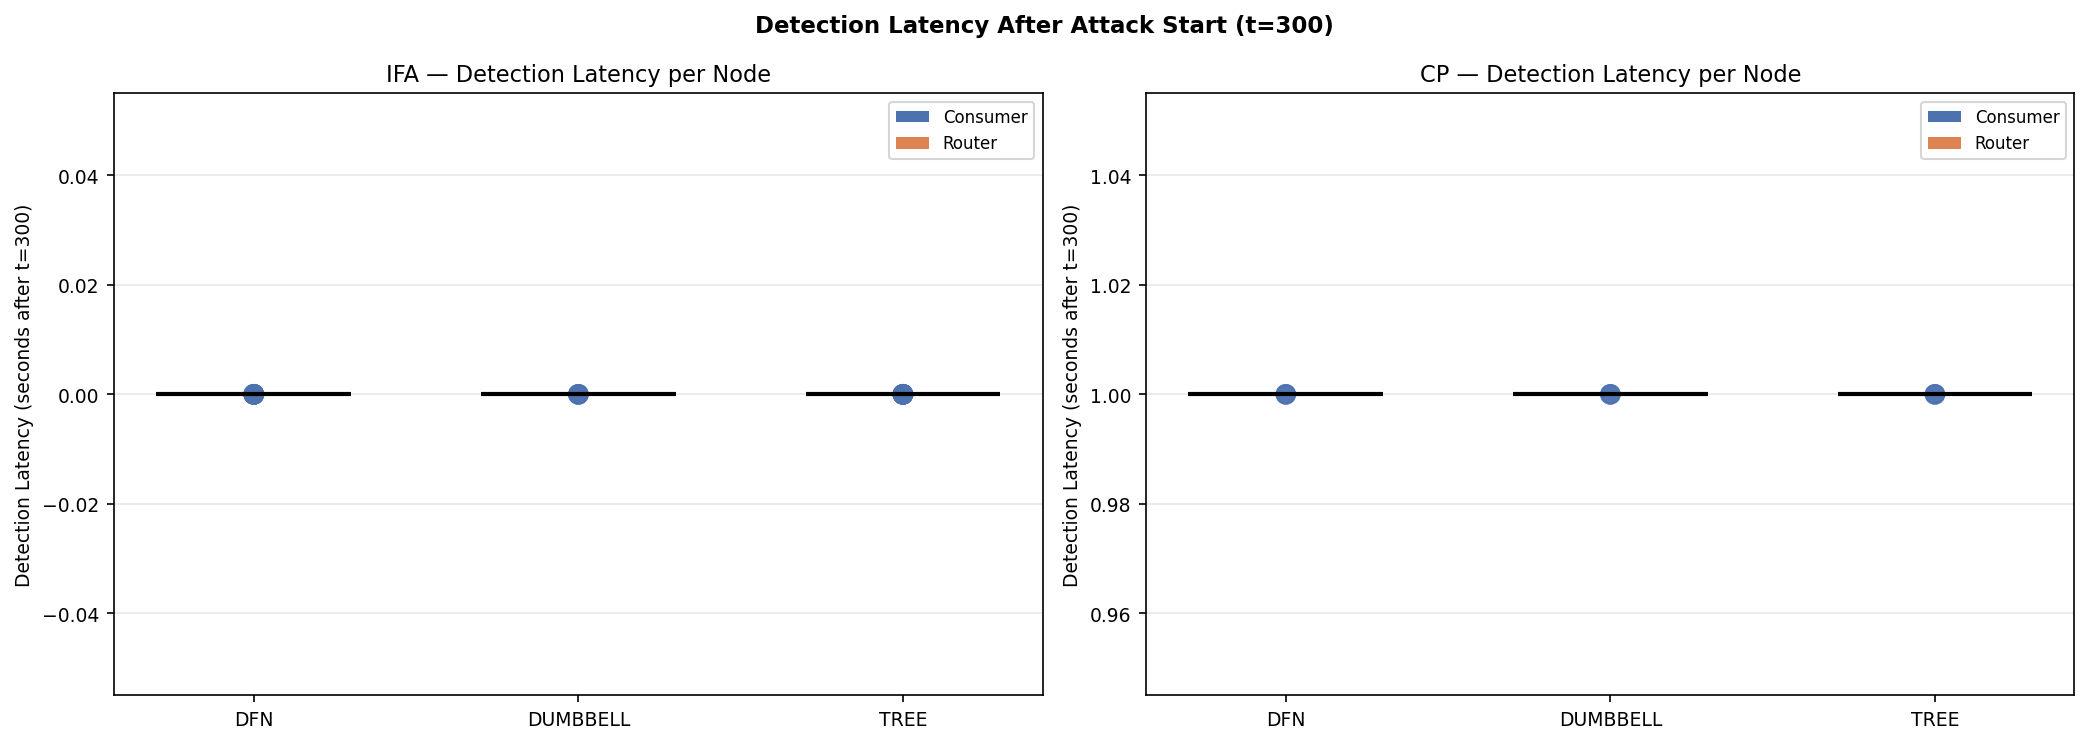

Saved fig_detection_latency.png


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col, attack in enumerate(["ifa", "cp"]):
    ax = axes[col]
    df_atk = df_latency[df_latency["attack"]==attack]

    for ti, topo in enumerate(TOPOLOGIES):
        df_t = df_atk[(df_atk["topology"]==topo) & (df_atk["detected"]==True)]
        if df_t.empty:
            continue
        ax.scatter(
            [ti] * len(df_t),
            df_t["latency_s"],
            c=[ROLE_COLORS[r] for r in df_t["role"]],
            s=80, alpha=0.8, zorder=3
        )
        # Mean line
        ax.hlines(df_t["latency_s"].mean(), ti - 0.3, ti + 0.3,
                  colors="black", linewidth=2, zorder=4)

    ax.set_xticks(range(len(TOPOLOGIES)))
    ax.set_xticklabels([t.upper() for t in TOPOLOGIES])
    ax.set_ylabel("Detection Latency (seconds after t=300)")
    ax.set_title(f"{attack.upper()} — Detection Latency per Node")
    ax.grid(axis="y", alpha=0.3)

    legend_handles = [
        Patch(facecolor=ROLE_COLORS["consumer"], label="Consumer"),
        Patch(facecolor=ROLE_COLORS["router"],   label="Router"),
    ]
    ax.legend(handles=legend_handles, fontsize=8)

plt.suptitle("Detection Latency After Attack Start (t=300)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_detection_latency.png", bbox_inches="tight")
plt.show()
print("Saved fig_detection_latency.png")

In [52]:
print("Building per-topology baselines...\n")
pertopo_parts = []

for topo in TOPOLOGIES:
    pt_baselines = compute_baseline_stats(train_normal, [topo])
    df_t = run_detector(full[full["topology"] == topo], pt_baselines)
    df_t["model"] = "per_topology"
    pertopo_parts.append(df_t)
    print(f"  {topo}: scored {df_t.shape[0]} rows")

full_pertopo = pd.concat(pertopo_parts, ignore_index=True)

print(f"\nAnomaly score by role × scenario (per-topology model):")
print(
    full_pertopo.groupby(["role", "scenario"])["anomaly_score"]
    .mean().round(2).unstack()
)

print(f"\nBefore/after t={ATTACK_START} — Global LOO vs Per-Topology:")
print(f"{'Topology-Attack':<20} {'LOO pre':>8} {'LOO post':>10} "
      f"{'PT pre':>8} {'PT post':>10} {'Lift LOO':>10} {'Lift PT':>8}")
print("-" * 82)

for topo in TOPOLOGIES:
    for attack in ["ifa", "cp"]:
        g = full_scored[
            (full_scored["topology"] == topo) &
            (full_scored["scenario"] == attack)
        ]
        p = full_pertopo[
            (full_pertopo["topology"] == topo) &
            (full_pertopo["scenario"] == attack)
        ]
        g_pre  = g[g["Time"] <  ATTACK_START]["anomaly_score"].mean()
        g_post = g[g["Time"] >= ATTACK_START]["anomaly_score"].mean()
        p_pre  = p[p["Time"] <  ATTACK_START]["anomaly_score"].mean()
        p_post = p[p["Time"] >= ATTACK_START]["anomaly_score"].mean()

        print(f"{topo}-{attack:<15} "
              f"{g_pre:>8.1f} {g_post:>10.1f} "
              f"{p_pre:>8.1f} {p_post:>10.1f} "
              f"{g_post-g_pre:>10.1f} {p_post-p_pre:>8.1f}")

Building per-topology baselines...

  Peer median std — consumer cache_hit_ratio: 0.1378 (from 6 nodes with real variance)
  Peer median std — router satisfaction_ratio: 0.2443 (from 4 nodes with real variance)
  Peer median std — router timeout_ratio: 0.4826 (from 5 nodes with real variance)

  Topo        Node Role       Feature                     mu   sigma  floored direction
  --------------------------------------------------------------------------------
  dfn            0 router     satisfaction_ratio      1.0000  0.2443      YES down
  dfn            0 router     timeout_ratio           0.7050  0.4572       no both
  dfn            1 router     satisfaction_ratio      0.0000  0.2443      YES up
  dfn            1 router     timeout_ratio           0.0000  0.4826      YES up
  dfn            2 router     satisfaction_ratio      0.0238  0.1062       no up
  dfn            2 router     timeout_ratio           0.5300  0.5004       no both
  dfn            3 router     satisfaction

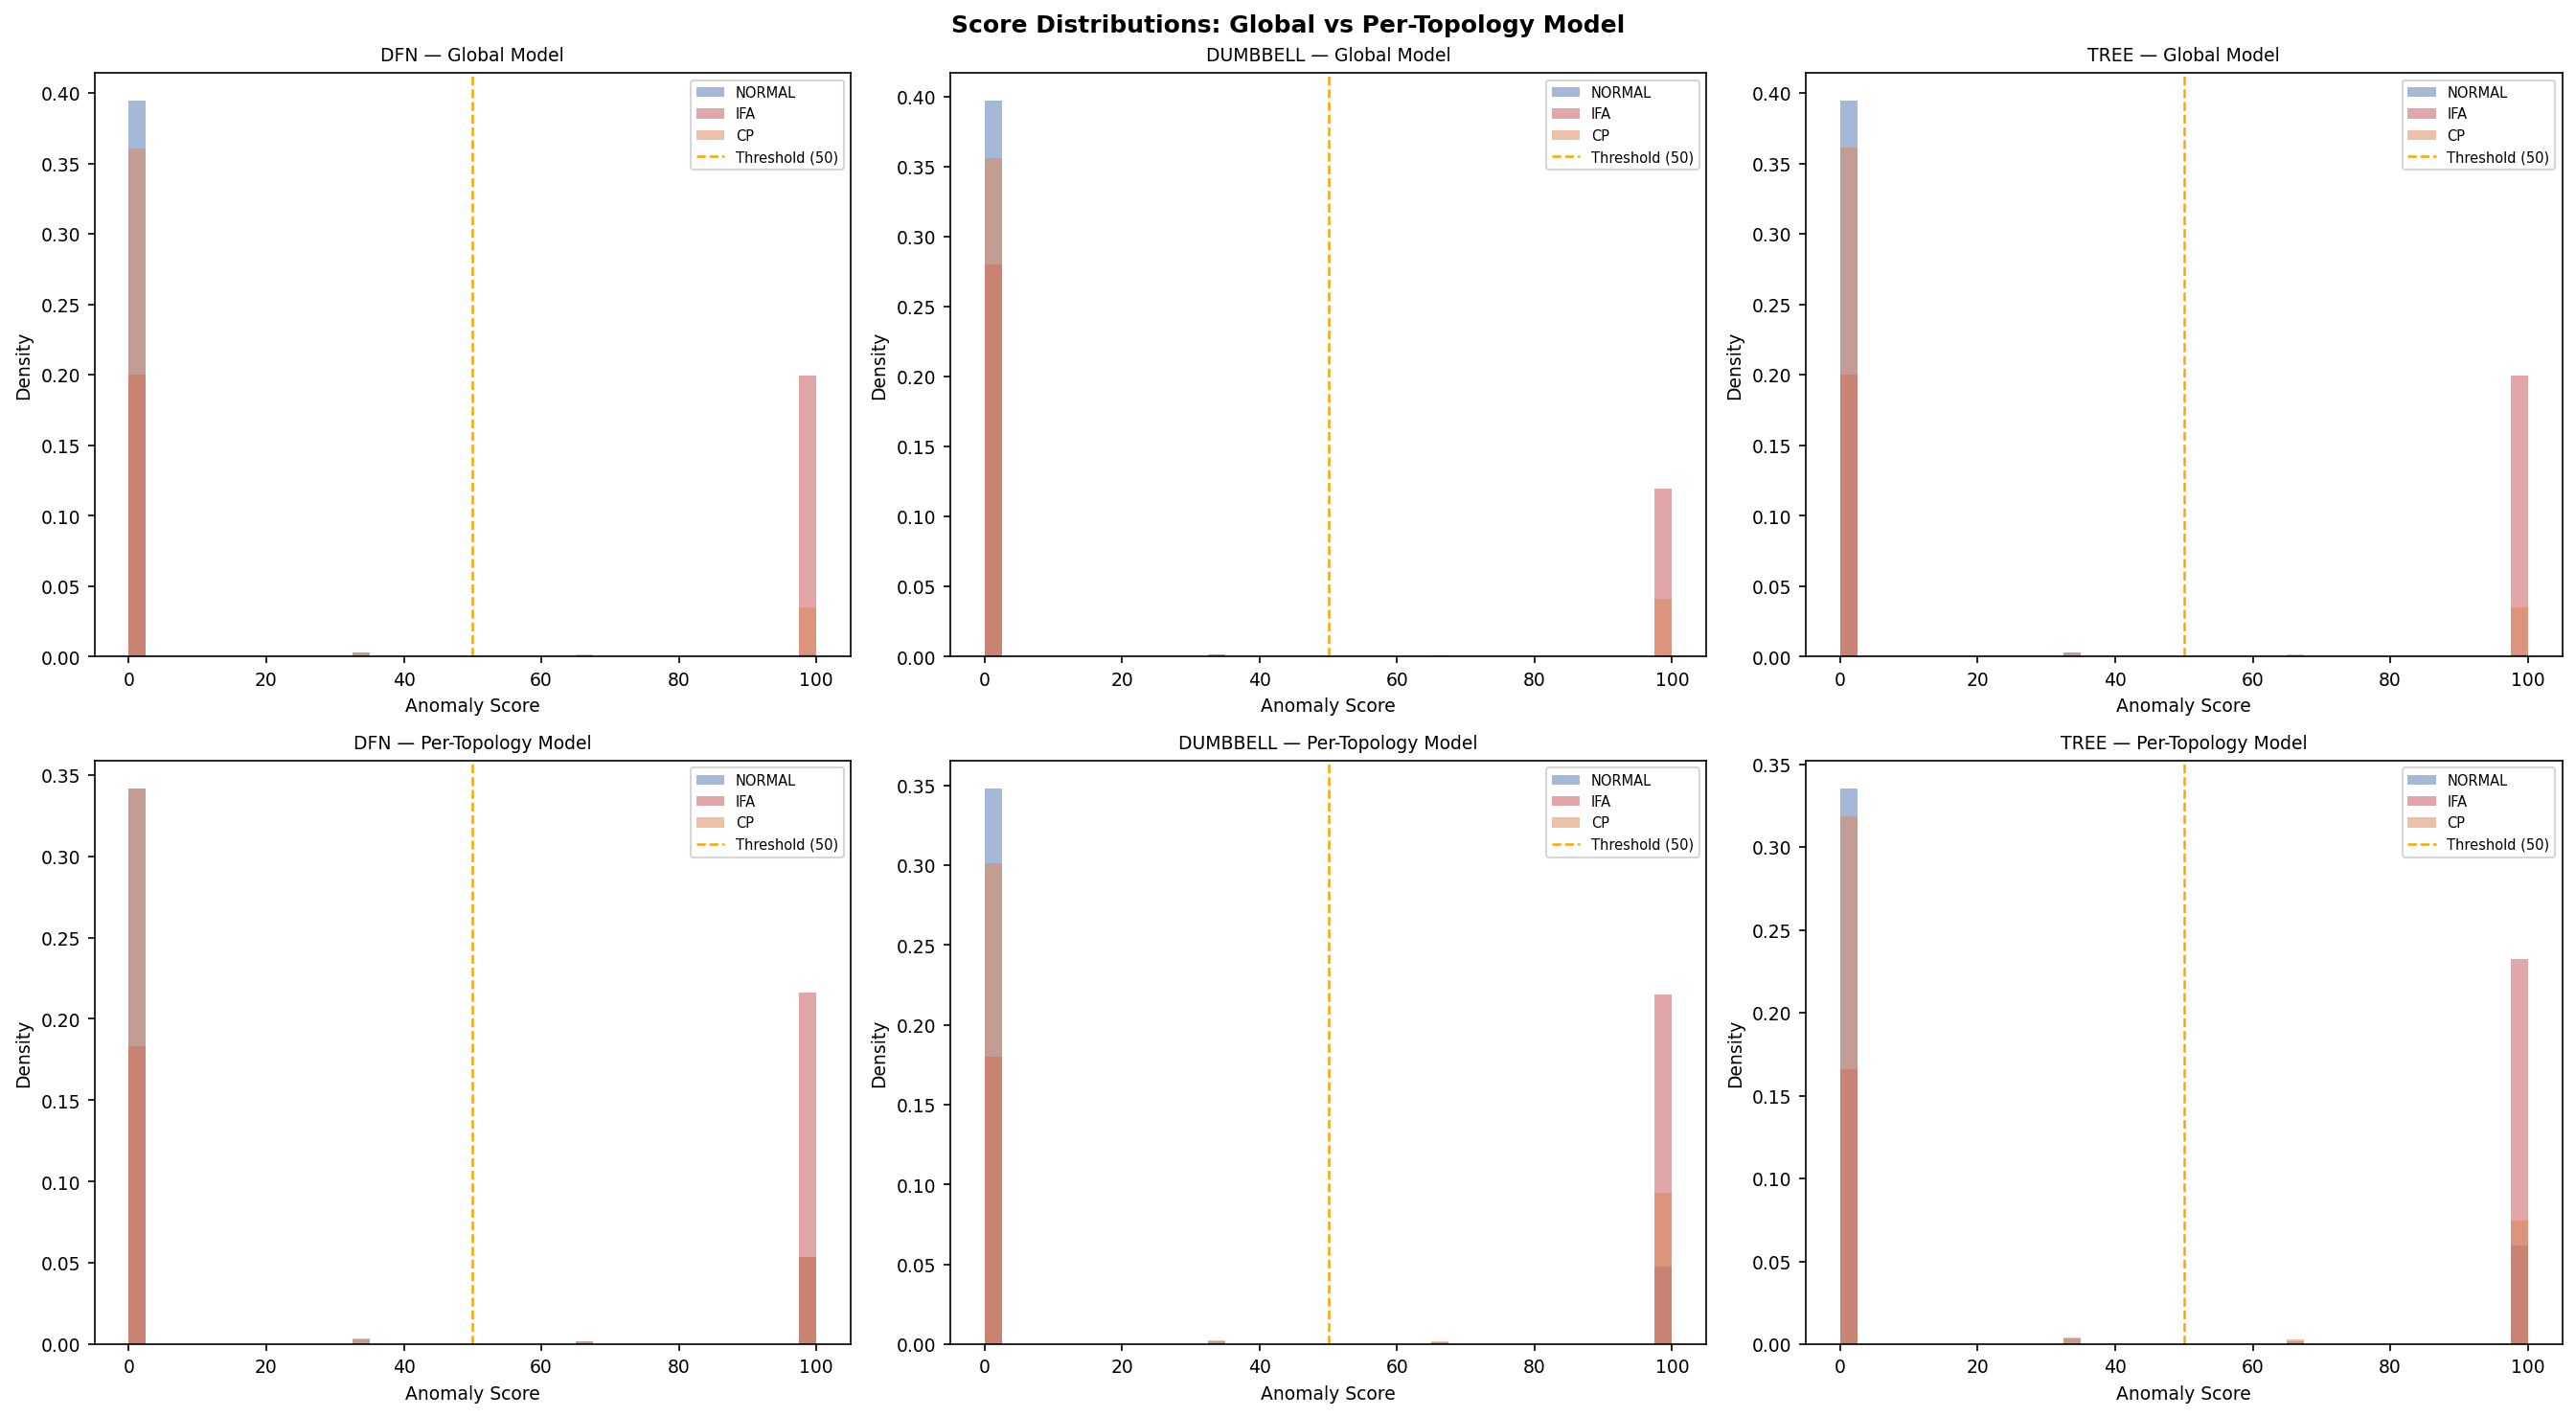

Saved fig_score_dist_comparison.png


In [53]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Score Distributions: Global vs Per-Topology Model",
             fontsize=12, fontweight="bold")

bins = np.linspace(0, 100, 41)

for col, topo in enumerate(TOPOLOGIES):
    for row, (scored_df, model_name) in enumerate([
        (full_scored,  "Global Model"),
        (full_pertopo, "Per-Topology Model")
    ]):
        ax = axes[row][col]

        for scenario, color in SCENARIO_COLORS.items():
            vals = scored_df[
                (scored_df["topology"]==topo) &
                (scored_df["scenario"]==scenario)
            ]["anomaly_score"]
            ax.hist(vals, bins=bins, alpha=0.5, color=color,
                    density=True, label=scenario.upper())

        ax.axvline(ALARM_THRESHOLD, color="orange", linestyle="--",
                   linewidth=1.2, label=f"Threshold ({ALARM_THRESHOLD})")
        ax.set_title(f"{topo.upper()} — {model_name}", fontsize=9)
        ax.set_xlabel("Anomaly Score")
        ax.set_ylabel("Density")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_score_dist_comparison.png", bbox_inches="tight")
plt.show()
print("Saved fig_score_dist_comparison.png")

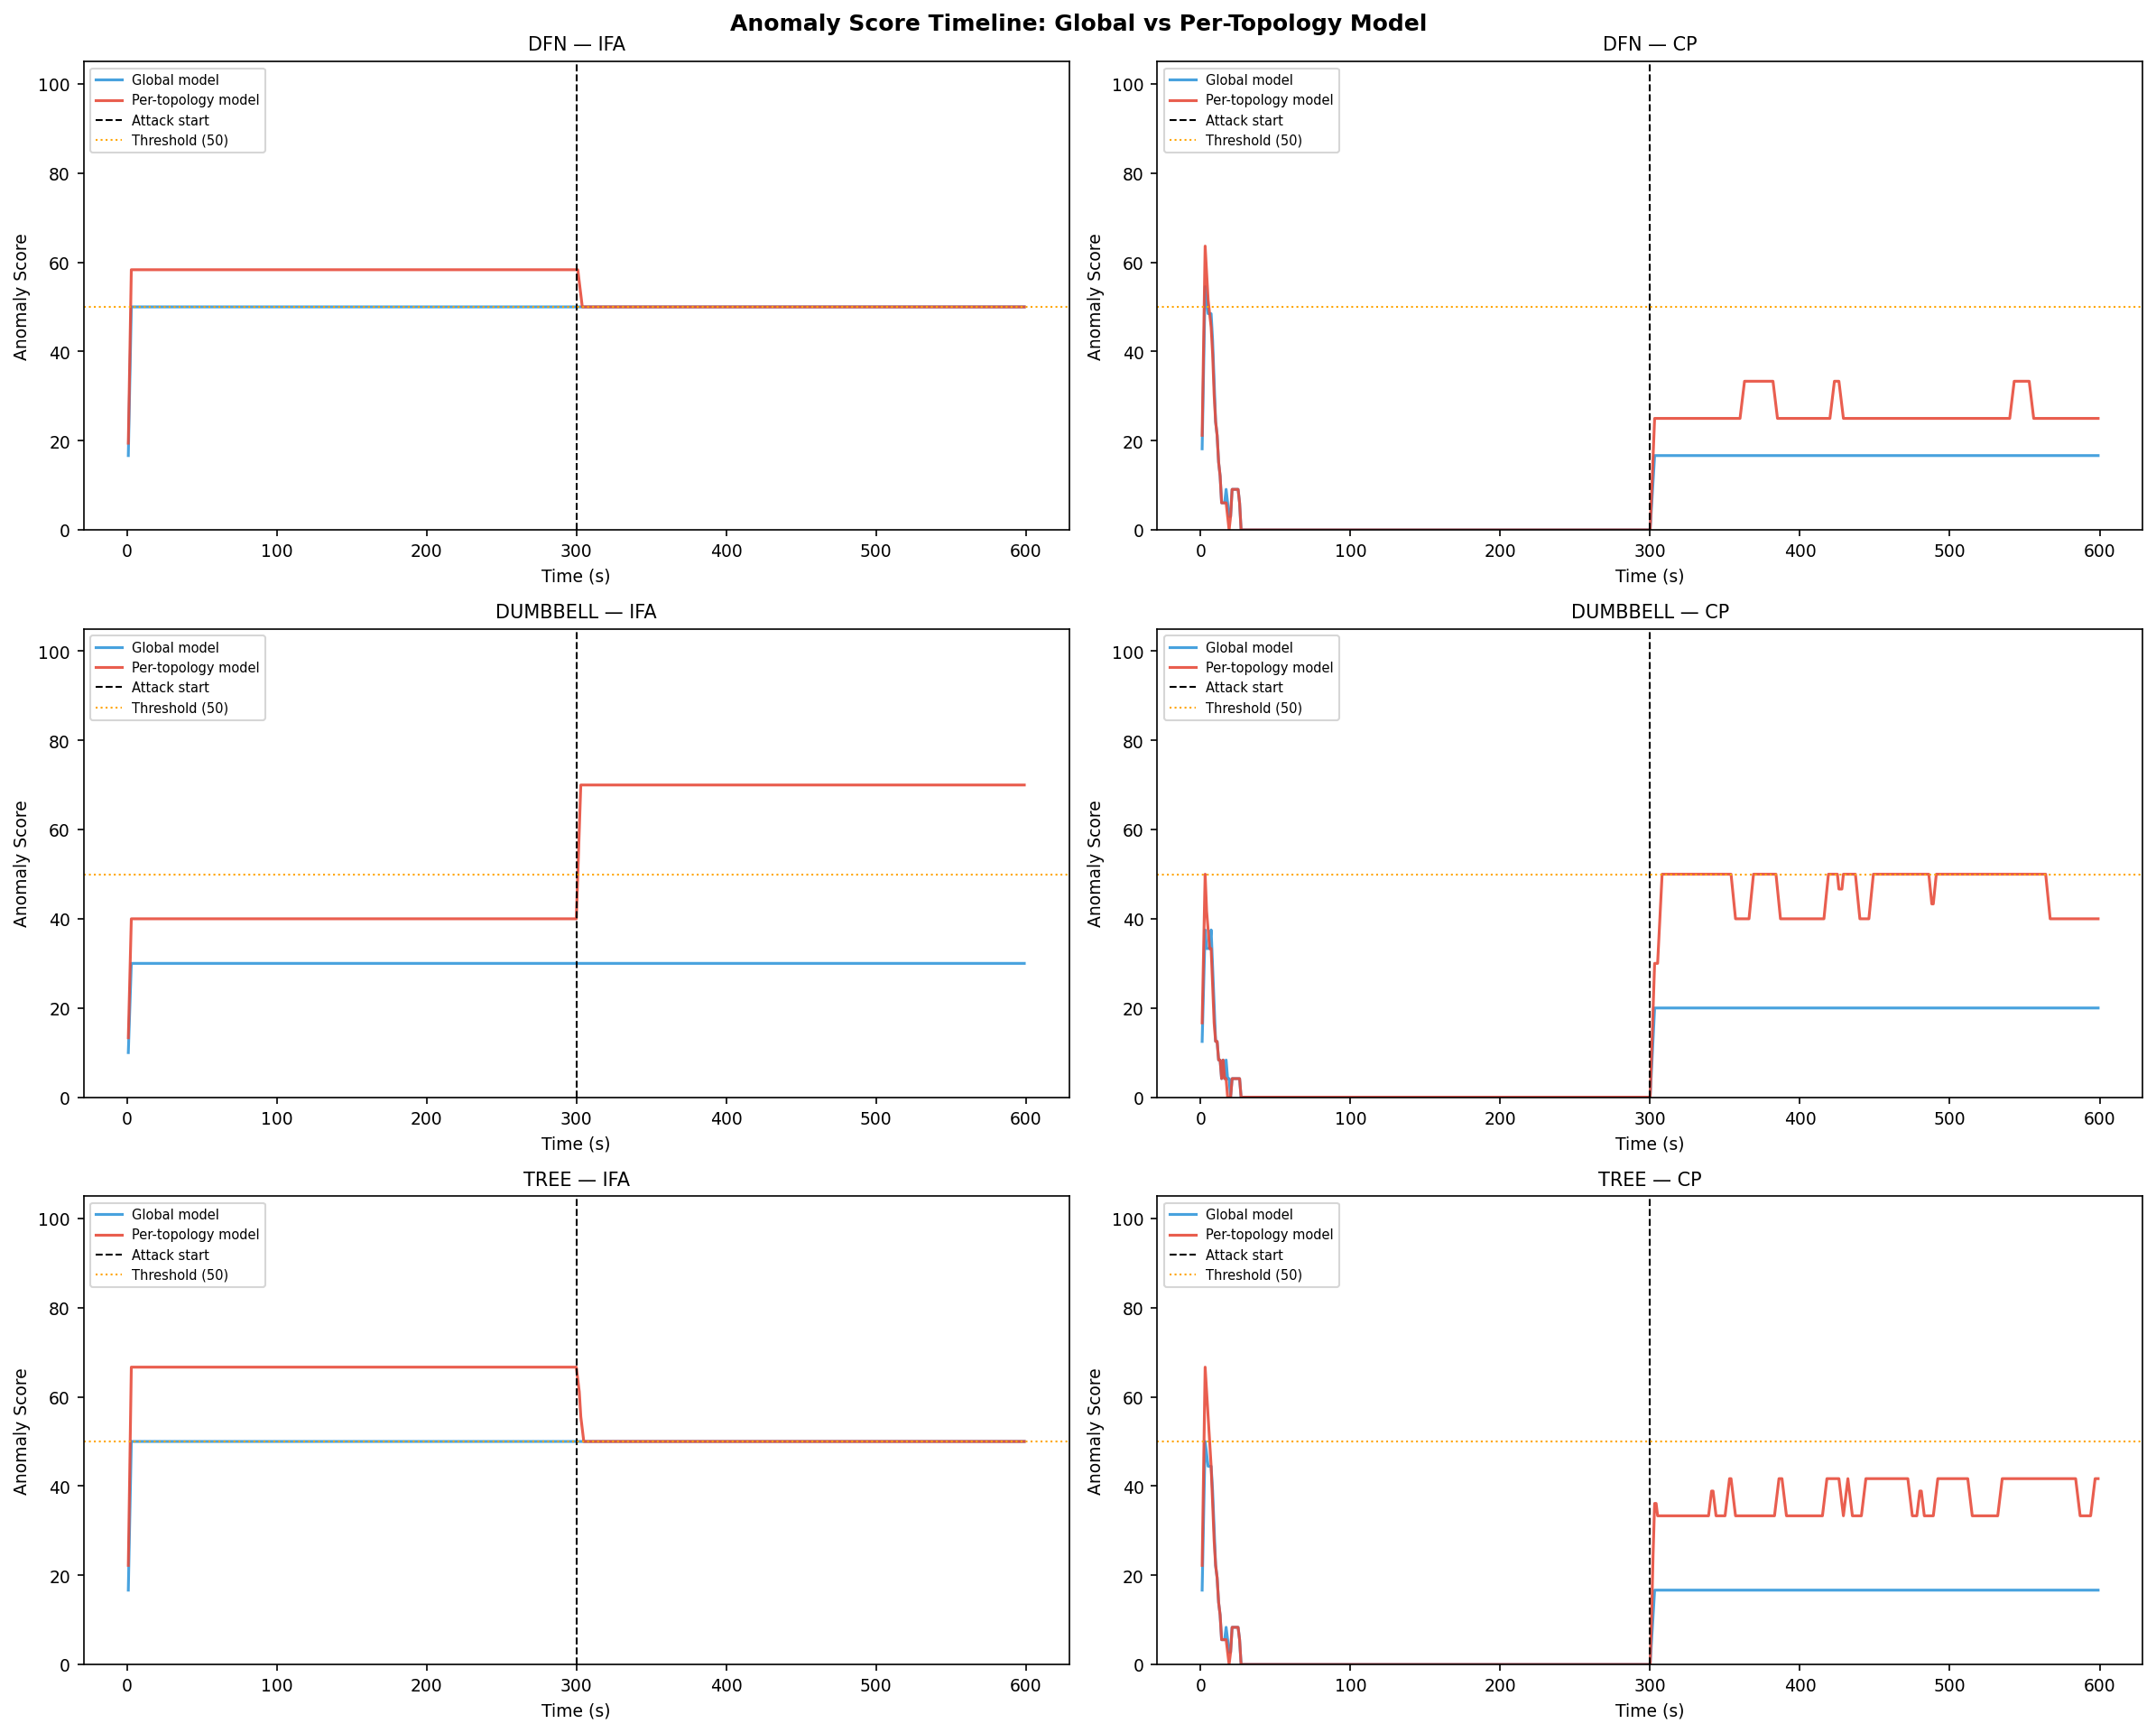

Saved fig_timeseries_comparison.png


In [54]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
fig.suptitle("Anomaly Score Timeline: Global vs Per-Topology Model",
             fontsize=12, fontweight="bold")

for row, topo in enumerate(TOPOLOGIES):
    for col, attack in enumerate(["ifa", "cp"]):
        ax = axes[row][col]

        g_ts = full_scored[
            (full_scored["topology"]==topo) &
            (full_scored["scenario"]==attack)
        ].groupby("Time")["anomaly_score"].mean()

        p_ts = full_pertopo[
            (full_pertopo["topology"]==topo) &
            (full_pertopo["scenario"]==attack)
        ].groupby("Time")["anomaly_score"].mean()

        ax.plot(g_ts.index, g_ts.values,
                color="#3498db", linewidth=1.5,
                label="Global model", alpha=0.9)
        ax.plot(p_ts.index, p_ts.values,
                color="#e74c3c", linewidth=1.5,
                label="Per-topology model", alpha=0.9)

        ax.axvline(300, color="black", linestyle="--",
                   linewidth=1.0, label="Attack start")
        ax.axhline(ALARM_THRESHOLD, color="orange", linestyle=":",
                   linewidth=1.0, label=f"Threshold ({ALARM_THRESHOLD})")

        ax.set_title(f"{topo.upper()} — {attack.upper()}", fontsize=10)
        ax.set_ylim(0, 105)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Anomaly Score")
        ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_timeseries_comparison.png", bbox_inches="tight")
plt.show()
print("Saved fig_timeseries_comparison.png")

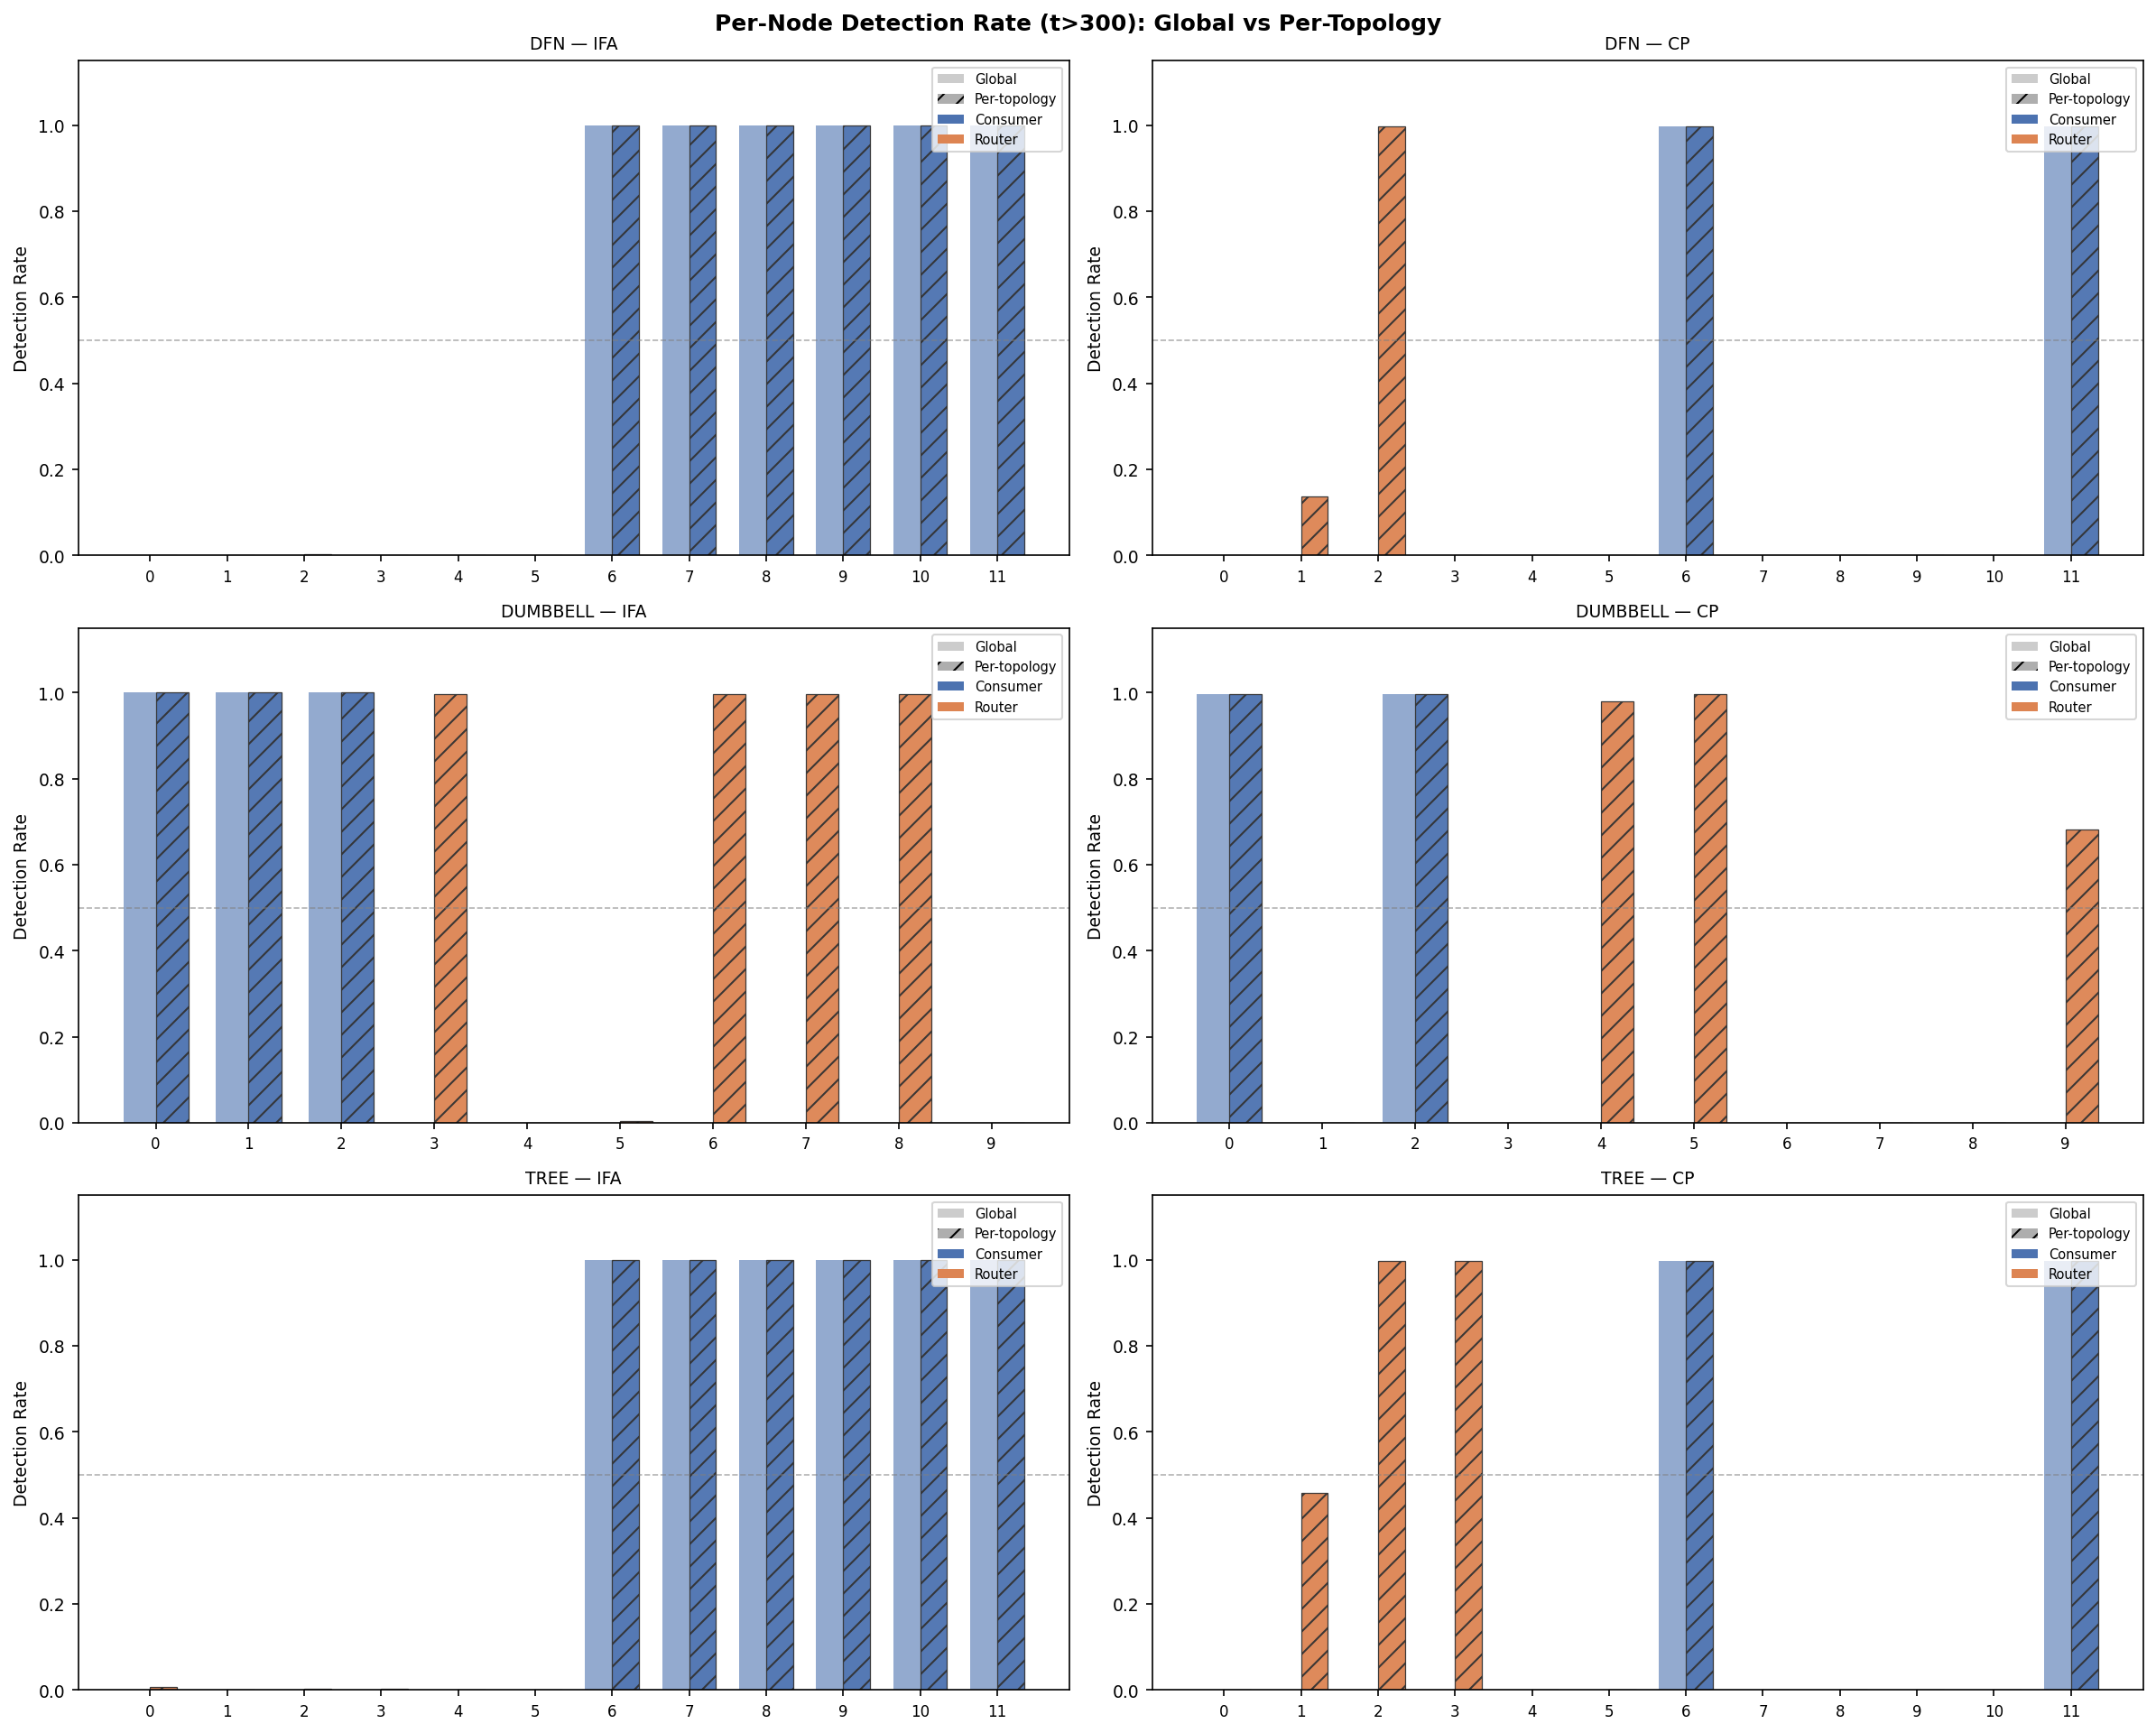

Saved fig_pernode_detection_comparison.png


In [55]:
def pernode_detection_rate(scored_df, topo, attack, threshold=ALARM_THRESHOLD):
    grp = scored_df[
        (scored_df["topology"]==topo) &
        (scored_df["scenario"]==attack) &
        (scored_df["Time"] > 300)
    ]
    return grp.groupby("Node").apply(
        lambda x: (x["anomaly_score"] > threshold).mean()
    )

fig, axes = plt.subplots(3, 2, figsize=(16, 13))
fig.suptitle("Per-Node Detection Rate (t>300): Global vs Per-Topology",
             fontsize=12, fontweight="bold")

for row, topo in enumerate(TOPOLOGIES):
    nodes = sorted(full[full["topology"]==topo]["Node"].unique())
    roles = full[full["topology"]==topo].groupby("Node")["role"].first()
    x     = np.arange(len(nodes))
    width = 0.35

    for col, attack in enumerate(["ifa", "cp"]):
        ax = axes[row][col]

        g_rates = pernode_detection_rate(full_scored,  topo, attack)
        p_rates = pernode_detection_rate(full_pertopo, topo, attack)

        g_vals = [g_rates.get(n, 0) for n in nodes]
        p_vals = [p_rates.get(n, 0) for n in nodes]
        colors = [ROLE_COLORS[roles[n]] for n in nodes]

        ax.bar(x - width/2, g_vals, width, color=colors,
               alpha=0.6, label="Global", edgecolor="none")
        ax.bar(x + width/2, p_vals, width, color=colors,
               alpha=0.95, label="Per-topology",
               edgecolor="#333", linewidth=0.6, hatch="//")

        ax.axhline(0.5, color="gray", linestyle="--",
                   linewidth=0.8, alpha=0.6)
        ax.set_xticks(x)
        ax.set_xticklabels(nodes, fontsize=8)
        ax.set_ylim(0, 1.15)
        ax.set_ylabel("Detection Rate")
        ax.set_title(f"{topo.upper()} — {attack.upper()}", fontsize=9)

        legend_handles = [
            Patch(facecolor="#aaa", alpha=0.6,  label="Global"),
            Patch(facecolor="#aaa", alpha=0.95, hatch="//", label="Per-topology"),
            Patch(facecolor=ROLE_COLORS["consumer"], label="Consumer"),
            Patch(facecolor=ROLE_COLORS["router"],   label="Router"),
        ]
        ax.legend(handles=legend_handles, fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_pernode_detection_comparison.png", bbox_inches="tight")
plt.show()
print("Saved fig_pernode_detection_comparison.png")

In [56]:
# Save scored CSVs
full_scored.to_csv(PROCESSED_DIR / "full_scored_global.csv", index=False)
full_pertopo.to_csv(PROCESSED_DIR / "full_scored_pertopo.csv", index=False)
print("Saved full_scored_global.csv")
print("Saved full_scored_pertopo.csv")

print("\n" + "="*75)
print("DETECTION SUMMARY — Temporal Lift (post - pre attack start)")
print("="*75)
print(f"{'Topology-Attack':<20} {'Global pre':>10} {'Global post':>12} "
      f"{'PerTopo pre':>12} {'PerTopo post':>13}")
print("-"*75)

for topo in TOPOLOGIES:
    for attack in ["ifa", "cp"]:
        g = full_scored[ (full_scored["topology"]==topo)  & (full_scored["scenario"]==attack)]
        p = full_pertopo[(full_pertopo["topology"]==topo) & (full_pertopo["scenario"]==attack)]

        g_pre  = g[g["Time"] <  ATTACK_START]["anomaly_score"].mean()
        g_post = g[g["Time"] >= ATTACK_START]["anomaly_score"].mean()
        p_pre  = p[p["Time"] <  ATTACK_START]["anomaly_score"].mean()
        p_post = p[p["Time"] >= ATTACK_START]["anomaly_score"].mean()

        print(f"{topo}-{attack:<15} {g_pre:>10.1f} {g_post:>12.1f} "
              f"{p_pre:>12.1f} {p_post:>13.1f}")

print("\n" + "="*75)
print("METHOD: Per-node static baseline z-score with persistence filter")
print(f"  Features         : {DETECT_FEATURES}")
print(f"  Baseline source  : train_normal.csv (normal scenario only, first {BASELINE_WINDOW}s)")
print(f"  Z threshold      : {Z_THRESHOLD}")
print(f"  Persistence      : {PERSIST_WINDOW} consecutive steps")
print(f"  Alarm threshold  : anomaly_score > {ALARM_THRESHOLD}")
print(f"  Attack boundary  : t >= {ATTACK_START} (GT shift-corrected)")
print("="*75)

print("\n" + "="*75)
print("KNOWN CONFOUNDS (from scenarios_info.md)")
print("="*75)
print("1. IFA scenarios use ConsumerCbr for legitimate traffic; normal baseline")
print("   was built from Zipf-Mandelbrot traffic. IFA lift includes a component")
print("   from this distributional difference, not purely the attack signal.")
print("   Do not compare IFA and CP lift values as if they are on the same scale.")
print("2. In CP scenarios, attacker nodes (c1, c6/c3) simultaneously run")
print("   legitimate and attack apps. Their per-node anomaly scores reflect")
print("   mixed traffic and cannot be cleanly attributed to attack detection alone.")

Saved full_scored_global.csv
Saved full_scored_pertopo.csv

DETECTION SUMMARY — Temporal Lift (post - pre attack start)
Topology-Attack      Global pre  Global post  PerTopo pre  PerTopo post
---------------------------------------------------------------------------
dfn-ifa                   49.8         50.0         58.1          50.1
dfn-cp                     1.7         16.6          1.7          26.1
dumbbell-ifa                   29.9         30.0         39.9          69.9
dumbbell-cp                     1.0         19.9          1.0          46.5
tree-ifa                   49.8         50.0         66.4          50.1
tree-cp                     1.7         16.6          1.8          37.1

METHOD: Per-node static baseline z-score with persistence filter
  Features         : ['satisfaction_ratio', 'timeout_ratio', 'cache_hit_ratio']
  Baseline source  : train_normal.csv (normal scenario only, first 200s)
  Z threshold      : 2.5
  Persistence      : 3 consecutive steps
  Alarm t